In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pybaseball import statcast

plt.style.use('seaborn-v0_8-whitegrid')

GAME_DATE = '2026-05-03'
OPPONENT = 'MIN'
RESULT = 'L 3-4'
STARTER_NAME = 'Yesavage, Trey'

print(f"=== Blue Jays Game Report: {GAME_DATE} vs {OPPONENT} ({RESULT}) ===")

=== Blue Jays Game Report: 2026-05-03 vs MIN (L 3-4) ===


In [2]:
game_data = statcast(start_dt=GAME_DATE, end_dt=GAME_DATE)

if 'TOR' in game_data['home_team'].values:
    jays_pitching = game_data[game_data['home_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    print("Blue Jays: HOME")
else:
    jays_pitching = game_data[game_data['away_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    print("Blue Jays: AWAY")

print(f"Total pitches in game: {len(game_data)}")
print(f"Blue Jays pitching data: {len(jays_pitchers)} pitches")
print(f"Blue Jays batting data: {len(jays_batting)} pitches")

This is a large query, it may take a moment to complete


  0%|                                                     | 0/1 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.91it/s]

Blue Jays: AWAY
Total pitches in game: 4241
Blue Jays pitching data: 140 pitches
Blue Jays batting data: 142 pitches


In [3]:
starter = jays_pitchers[jays_pitchers['player_name'] == STARTER_NAME]
print(f"{STARTER_NAME} total pitches: {len(starter)}")
print(f"\n=== Pitch Mix ===")
print(starter['pitch_type'].value_counts())
print(f"\n=== Avg Velocity by Pitch ===")
velo = starter.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
velo = velo[velo['count'] >= 2].sort_values('mean', ascending=False)
print(velo.round(1))

Yesavage, Trey total pitches: 82

=== Pitch Mix ===
pitch_type
FF    46
FS    28
SL     8
Name: count, dtype: int64

=== Avg Velocity by Pitch ===
            mean  count
pitch_type             
FF          93.3     46
SL          86.9      8
FS          80.8     28


In [4]:
print("=== Pitch Movement (inches) ===")
movement = starter.groupby('pitch_type').agg(
    h_break=('pfx_x', lambda x: x.mean() * 12),
    v_break=('pfx_z', lambda x: x.mean() * 12),
    count=('pitch_type', 'count')
).round(1)
movement = movement[movement['count'] >= 2]
print(movement)

=== Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
FF             -6.0     19.5     46
FS            -11.8      6.2     28
SL             -5.7      4.9      8


Chart saved!


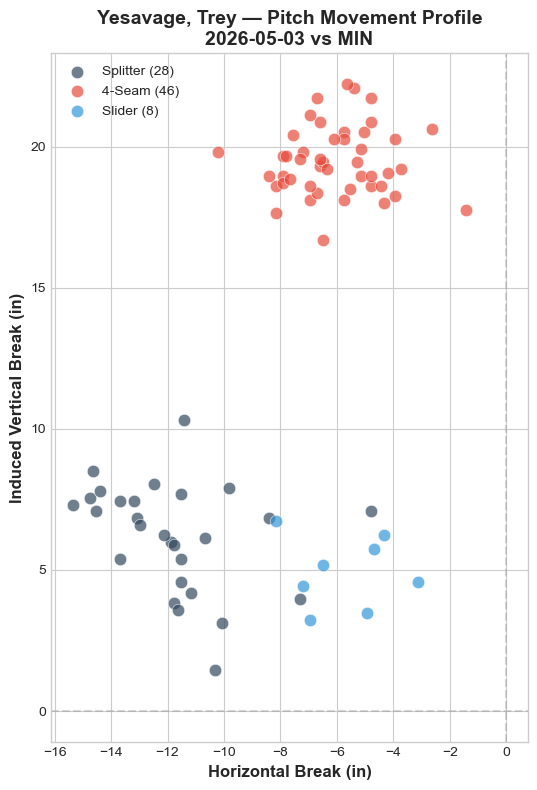

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

pitch_colors = {
    'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
    'CU': '#f39c12', 'SI': '#1abc9c', 'FC': '#95a5a6',
    'ST': '#9b59b6', 'KC': '#e67e22', 'FS': '#34495e'
}
pitch_names = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'CU': 'Curveball', 'SI': 'Sinker', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve', 'FS': 'Splitter'
}

for pt in starter['pitch_type'].unique():
    data = starter[starter['pitch_type'] == pt].dropna(subset=['pfx_x', 'pfx_z'])
    if len(data) >= 2:
        ax.scatter(data['pfx_x'] * 12, data['pfx_z'] * 12,
                   c=pitch_colors.get(pt, '#95a5a6'), s=80, alpha=0.7,
                   label=f"{pitch_names.get(pt, pt)} ({len(data)})",
                   edgecolors='white', linewidth=0.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Horizontal Break (in)', fontsize=12, fontweight='bold')
ax.set_ylabel('Induced Vertical Break (in)', fontsize=12, fontweight='bold')
ax.set_title(f'{STARTER_NAME} — Pitch Movement Profile\n{GAME_DATE} vs {OPPONENT}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'../visualizations/movement_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [6]:
print(f"=== {STARTER_NAME} vs LHB/RHB ===")
lr_split = starter.groupby('stand').agg(
    pitches=('pitch_type', 'count'),
    avg_velo=('release_speed', 'mean'),
    swinging_strikes=('description', lambda x: (x.isin(['swinging_strike', 'swinging_strike_blocked'])).sum())
).round(1)
lr_split['whiff_per_pitch'] = (lr_split['swinging_strikes'] / lr_split['pitches'] * 100).round(1)
print(lr_split)

=== Yesavage, Trey vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L           38      86.5                 9             23.7
R           44      90.0                 6             13.6


Chart saved!


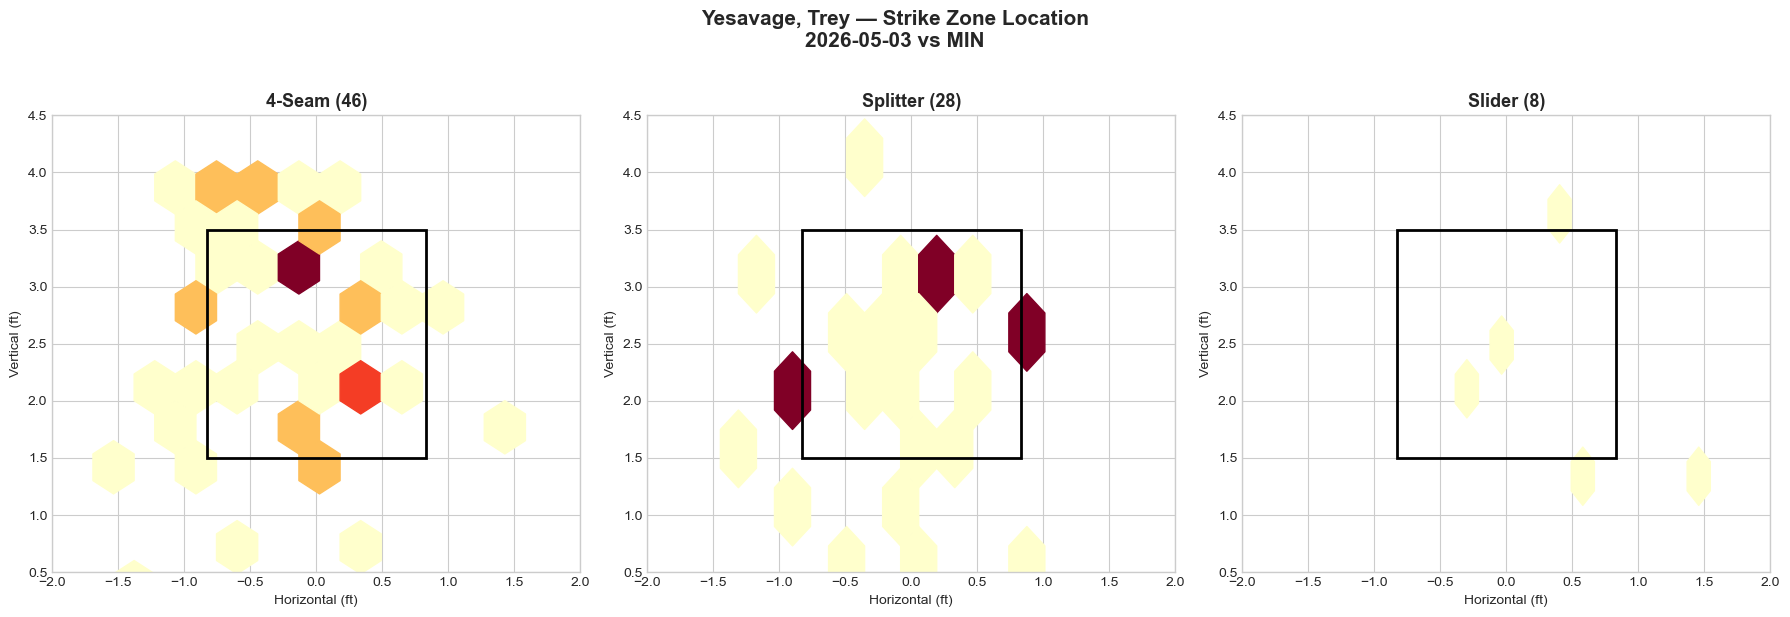

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

main_pitches = starter['pitch_type'].value_counts().head(3).index.tolist()

for idx, pt in enumerate(main_pitches):
    ax = axes[idx]
    data = starter[starter['pitch_type'] == pt].dropna(subset=['plate_x', 'plate_z'])

    if len(data) > 0:
        ax.hexbin(data['plate_x'], data['plate_z'], gridsize=10, cmap='YlOrRd', mincnt=1)

        # Strike zone box (approximate)
        zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False,
                              edgecolor='black', linewidth=2)
        ax.add_patch(zone)

        ax.set_xlim(-2, 2)
        ax.set_ylim(0.5, 4.5)
        ax.set_title(f'{pitch_names.get(pt, pt)} ({len(data)})',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Horizontal (ft)', fontsize=10)
        ax.set_ylabel('Vertical (ft)', fontsize=10)

plt.suptitle(f'{STARTER_NAME} — Strike Zone Location\n{GAME_DATE} vs {OPPONENT}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../visualizations/zone_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [8]:
starter_with_count = starter.dropna(subset=['balls', 'strikes']).copy()
starter_with_count['count'] = starter_with_count['balls'].astype(int).astype(str) + '-' + starter_with_count['strikes'].astype(int).astype(str)

count_groups = {
    'First pitch (0-0)': ['0-0'],
    'Ahead (0-1, 0-2, 1-2)': ['0-1', '0-2', '1-2'],
    'Behind (1-0, 2-0, 3-0, 2-1, 3-1)': ['1-0', '2-0', '3-0', '2-1', '3-1'],
    'Even (1-1, 2-2)': ['1-1', '2-2'],
    'Full count (3-2)': ['3-2']
}

print(f"=== {STARTER_NAME} — Pitch Selection by Count ===\n")

for group_name, counts in count_groups.items():
    group_data = starter_with_count[starter_with_count['count'].isin(counts)]
    if len(group_data) > 0:
        mix = group_data['pitch_type'].value_counts(normalize=True).mul(100).round(1)
        print(f"--- {group_name} ({len(group_data)} pitches) ---")
        for pt, pct in mix.items():
            print(f"  {pitch_names.get(pt, pt)}: {pct}%")
        print()

# Strikeout pitch analysis
strikeouts = starter[starter['events'] == 'strikeout']
if len(strikeouts) > 0:
    print(f"=== Strikeout Pitch ({len(strikeouts)} K's) ===")
    print(strikeouts['pitch_type'].value_counts())

=== Yesavage, Trey — Pitch Selection by Count ===

--- First pitch (0-0) (20 pitches) ---
  4-Seam: 60.0%
  Splitter: 30.0%
  Slider: 10.0%

--- Ahead (0-1, 0-2, 1-2) (25 pitches) ---
  Splitter: 60.0%
  4-Seam: 32.0%
  Slider: 8.0%

--- Behind (1-0, 2-0, 3-0, 2-1, 3-1) (21 pitches) ---
  4-Seam: 81.0%
  Splitter: 14.3%
  Slider: 4.8%

--- Even (1-1, 2-2) (11 pitches) ---
  Splitter: 36.4%
  4-Seam: 36.4%
  Slider: 27.3%

--- Full count (3-2) (5 pitches) ---
  4-Seam: 100.0%

=== Strikeout Pitch (6 K's) ===
pitch_type
FF    5
FS    1
Name: count, dtype: int64


In [9]:
# Find opposing batters who saw the most pitches from our starter
batter_summary = starter.groupby('player_name').agg(
    pitches=('pitch_type', 'count'),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: (x == 'walk').sum()),
    avg_exit_velo=('launch_speed', lambda x: x.dropna().mean() if len(x.dropna()) > 0 else np.nan)
).sort_values('pitches', ascending=False)

print(f"=== Top Opposing Batters vs {STARTER_NAME} ===\n")

top_batters = batter_summary.head(5)
print(top_batters.round(1))

# Detailed breakdown for top 3
print("\n=== Detailed Pitch Breakdown ===\n")
for batter_name in batter_summary.head(3).index:
    batter_data = starter[starter['player_name'] == batter_name]
    print(f"--- {batter_name} ({len(batter_data)} pitches) ---")
    print(f"  Pitches faced: {batter_data['pitch_type'].value_counts().to_dict()}")

    results = batter_data['description'].value_counts()
    whiffs = results.get('swinging_strike', 0) + results.get('swinging_strike_blocked', 0)
    fouls = results.get('foul', 0) + results.get('foul_tip', 0)
    called = results.get('called_strike', 0)
    balls = results.get('ball', 0) + results.get('blocked_ball', 0)
    in_play = results.get('hit_into_play', 0) + results.get('hit_into_play_no_out', 0)

    print(f"  Results: {whiffs} whiffs, {fouls} fouls, {called} called strikes, {balls} balls, {in_play} in play")

    events = batter_data['events'].dropna()
    if len(events) > 0:
        print(f"  Outcomes: {events.tolist()}")
    print()

=== Top Opposing Batters vs Yesavage, Trey ===

                pitches  hits  strikeouts  walks  avg_exit_velo
player_name                                                    
Yesavage, Trey       82     5           6      3           81.6

=== Detailed Pitch Breakdown ===

--- Yesavage, Trey (82 pitches) ---
  Pitches faced: {'FF': 46, 'FS': 28, 'SL': 8}
  Results: 15 whiffs, 14 fouls, 12 called strikes, 30 balls, 11 in play
  Outcomes: ['field_out', 'walk', 'strikeout', 'field_out', 'strikeout', 'walk', 'double', 'strikeout', 'single', 'strikeout', 'strikeout', 'single', 'field_out', 'strikeout', 'field_out', 'field_out', 'single', 'walk', 'single', 'field_out']



Chart saved!


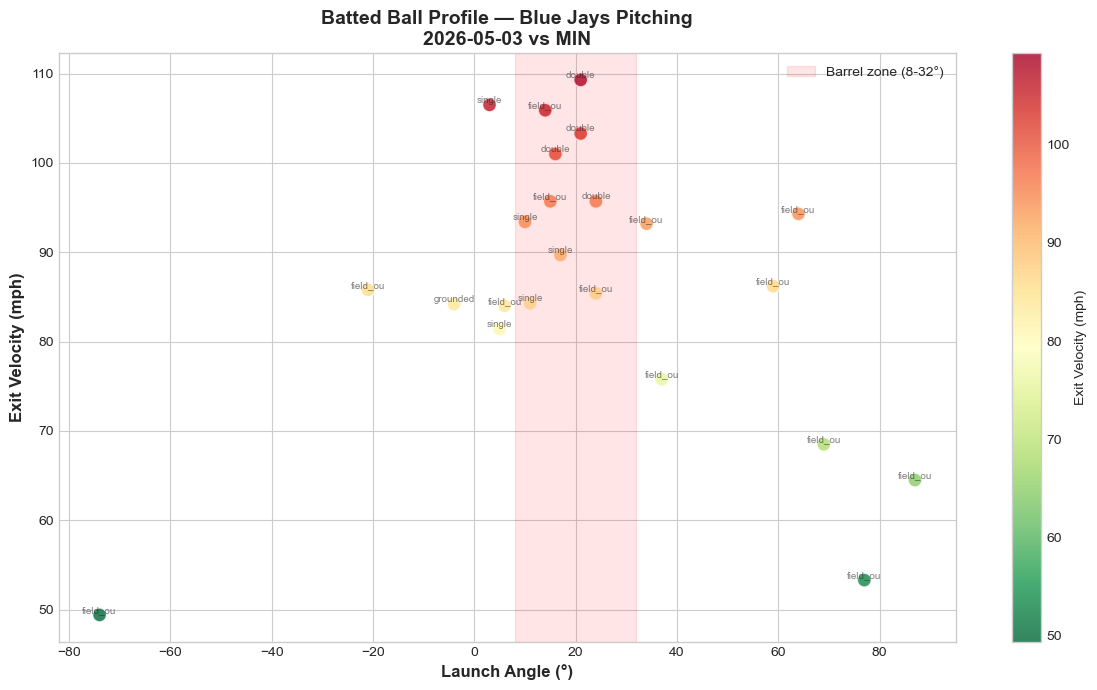


=== Batted Ball Summary ===
Total balls in play: 23
Avg exit velocity: 86.6 mph
Avg launch angle: 22.4°
Hard hit (95+ mph): 7/23


In [10]:
in_play = jays_pitchers[jays_pitchers['description'] == 'hit_into_play'].dropna(subset=['launch_angle', 'launch_speed'])

if len(in_play) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    scatter = ax.scatter(in_play['launch_angle'], in_play['launch_speed'],
                         c=in_play['launch_speed'], cmap='RdYlGn_r',
                         s=100, edgecolors='white', linewidth=1, alpha=0.8)
    for _, row in in_play.iterrows():
        result = row.get('events', '')
        if pd.notna(result) and result != '':
            ax.annotate(result[:8], xy=(row['launch_angle'], row['launch_speed']),
                        fontsize=7, alpha=0.6, ha='center', va='bottom')
    ax.axvspan(8, 32, alpha=0.1, color='red', label='Barrel zone (8-32°)')
    ax.set_xlabel('Launch Angle (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Exit Velocity (mph)', fontsize=12, fontweight='bold')
    ax.set_title(f'Batted Ball Profile — Blue Jays Pitching\n{GAME_DATE} vs {OPPONENT}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(scatter, label='Exit Velocity (mph)')
    plt.tight_layout()
    plt.savefig(f'../visualizations/batted_balls_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()
    print(f"\n=== Batted Ball Summary ===")
    print(f"Total balls in play: {len(in_play)}")
    print(f"Avg exit velocity: {in_play['launch_speed'].mean():.1f} mph")
    print(f"Avg launch angle: {in_play['launch_angle'].mean():.1f}°")
    print(f"Hard hit (95+ mph): {(in_play['launch_speed'] >= 95).sum()}/{len(in_play)}")

In [11]:
game_data.to_csv(f'../data/game_{GAME_DATE}.csv', index=False)
print(f"Game data saved: {len(game_data)} pitches")

Game data saved: 4241 pitches
